# 07 — Seasonal Breakdown (Dry vs Wet)

**Author:** Sharon Christa 
**Date:** April 2026  
**Purpose:** Split MODIS LST by season and test whether UHI patterns differ between dry and wet months, and whether seasonal warming trends diverge.

### Why this matters

Tropical UHI has **strong seasonality**. Siswanto et al. (2023) report that Jakarta's daytime SUHI peaks in SON (transition) and is lowest in JJA (dry). Nighttime SUHI behaves differently. For our two cities:

- **Dar es Salaam** has *strong* seasonality (bimodal rainfall, clear dry season June-October). We expect **larger seasonal LST contrast**.
- **Singapore** is equatorial with two wet monsoons (NE Dec-Mar, SW Jun-Sep). Seasonality is *weaker* — more humidity year-round buffers LST.

### Seasons defined

| City | Dry season | Wet season |
|---|---|---|
| Dar es Salaam | Jun–Oct (long dry) | Mar–May + Nov–Dec (rains) |
| Singapore | Jun–Sep (SW monsoon, drier) | Dec–Mar (NE monsoon, wetter) |

Jan–Feb for Dar and Apr–May/Oct–Nov for Singapore are left as "transition" and excluded from the simple binary analysis. (They can be added back if you want a four-season breakdown.)

### What this notebook produces

1. Seasonal LST composites for each city, each year, day and night
2. Seasonal trend fits (°C/decade) — wet vs dry, day vs night
3. LCZ × season × LST table — is the hottest LCZ even hotter in the dry season?
4. 3 poster-ready figures
5. CSV outputs for notebook 06 to incorporate

## 1. Setup

In [3]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

# Direct init — no helper, no try/except masking errors
ee.Initialize(project='black-octagon-291810')
print("EE initialised successfully")
print(f"Project: black-octagon-291810")

# Sanity check — should print "1"
test = ee.Number(1).getInfo()
print(f"GEE round-trip test: {test}")

EE initialised successfully
Project: black-octagon-291810
GEE round-trip test: 1


## 2. AOIs (unchanged)

In [4]:
aoi_dar = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1")
           .filter(ee.Filter.eq("gaul1_name", "Dar Es Salaam")))
dar_geom = aoi_dar.geometry()

aoi_sgp = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L0")
           .filter(ee.Filter.eq("gaul0_name", "Singapore")))
sgp_geom = aoi_sgp.geometry()

## 3. Seasonal definitions and LST pipeline

Seasons are city-specific — we define each as a **list of calendar month numbers**. `get_seasonal_lst()` filters the MODIS collection to only those months of a given year.

In [5]:
# Season month mappings. Months are 1-12.
SEASONS = {
    'Dar es Salaam': {
        'dry': [6, 7, 8, 9, 10],         # long dry season
        'wet': [3, 4, 5, 11, 12],        # long + short rains
    },
    'Singapore': {
        'dry': [6, 7, 8, 9],             # SW monsoon, drier half
        'wet': [12, 1, 2, 3],            # NE monsoon, wettest
    },
}

BANDS = {'day': 'LST_Day_1km', 'night': 'LST_Night_1km'}
YEARS = [2005, 2010, 2015, 2020, 2025]


def prepare_lst(image, band):
    """Scale MODIS LST to °C."""
    return (image.select(band)
                 .multiply(0.02).subtract(273.15)
                 .copyProperties(image, ['system:time_start']))


def get_seasonal_lst(geom, year, band, months):
    """Annual MODIS median LST for a specific year, restricted to given months."""
    start = f'{year}-01-01'
    end   = f'{year}-12-31'
    col = (ee.ImageCollection("MODIS/061/MOD11A2")
             .filterBounds(geom)
             .filterDate(start, end)
             .filter(ee.Filter.calendarRange(min(months), max(months), 'month'))
             .map(lambda img: prepare_lst(img, band)))
    # If season crosses year boundary (Singapore wet = Dec-Mar),
    # calendarRange handles non-contiguous months via a list filter:
    if max(months) - min(months) + 1 != len(months):
        # Non-contiguous; use .filter on calendarRange per month
        month_filters = [ee.Filter.calendarRange(m, m, 'month') for m in months]
        combined_filter = ee.Filter.Or(*month_filters)
        col = (ee.ImageCollection("MODIS/061/MOD11A2")
                 .filterBounds(geom)
                 .filterDate(start, end)
                 .filter(combined_filter)
                 .map(lambda img: prepare_lst(img, band)))
    return col.median().clip(geom).rename(band)


# Build composites: composites[city][year][season][tod] = EE image
composites = {'Dar es Salaam': {}, 'Singapore': {}}
for city, geom in [('Dar es Salaam', dar_geom), ('Singapore', sgp_geom)]:
    for year in YEARS:
        composites[city][year] = {}
        for season, months in SEASONS[city].items():
            composites[city][year][season] = {
                tod: get_seasonal_lst(geom, year, band, months)
                for tod, band in BANDS.items()
            }

n = len(YEARS) * 2 * 2  # 2 seasons × 2 tod per city
print(f"Built {n} seasonal composites per city = {n*2} total. Ready for stats.")

Built 20 seasonal composites per city = 40 total. Ready for stats.


## 4. Extract seasonal mean LST — the main table

In [6]:
def extract_mean(image, geom, band_name):
    stats = image.reduceRegion(
        reducer=ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True),
        geometry=geom,
        scale=1000,
        maxPixels=1e9,
    ).getInfo()
    return stats.get(f'{band_name}_mean'), stats.get(f'{band_name}_stdDev')


rows = []
for city, geom in [('Dar es Salaam', dar_geom), ('Singapore', sgp_geom)]:
    for year in YEARS:
        for season in ['dry', 'wet']:
            for tod, band in BANDS.items():
                mean, std = extract_mean(composites[city][year][season][tod], geom, band)
                rows.append({
                    'city': city,
                    'year': year,
                    'season': season,
                    'tod': tod,
                    'mean': mean,
                    'std': std,
                })
                print(f"  {city[:3]} {year} {season} {tod}: {mean:.2f}°C ± {std:.2f}")

season_df = pd.DataFrame(rows)
season_df.head(12)

  Dar 2005 dry day: 31.12°C ± 1.69
  Dar 2005 dry night: 20.45°C ± 1.02
  Dar 2005 wet day: 34.00°C ± 1.92
  Dar 2005 wet night: 22.89°C ± 0.64
  Dar 2010 dry day: 31.23°C ± 1.46
  Dar 2010 dry night: 20.79°C ± 0.98
  Dar 2010 wet day: 34.37°C ± 1.76
  Dar 2010 wet night: 23.61°C ± 0.57
  Dar 2015 dry day: 31.22°C ± 1.42
  Dar 2015 dry night: 21.07°C ± 0.92
  Dar 2015 wet day: 34.79°C ± 2.15
  Dar 2015 wet night: 23.56°C ± 0.48
  Dar 2020 dry day: 32.01°C ± 1.46
  Dar 2020 dry night: 21.57°C ± 0.75
  Dar 2020 wet day: 31.86°C ± 2.26
  Dar 2020 wet night: 23.56°C ± 0.56
  Dar 2025 dry day: 27.53°C ± 1.12
  Dar 2025 dry night: 21.99°C ± 0.68
  Dar 2025 wet day: 30.74°C ± 1.69
  Dar 2025 wet night: 24.64°C ± 0.50
  Sin 2005 dry day: 32.14°C ± 2.70
  Sin 2005 dry night: 25.21°C ± 0.73
  Sin 2005 wet day: 32.80°C ± 2.34
  Sin 2005 wet night: 24.25°C ± 0.65
  Sin 2010 dry day: 32.60°C ± 2.76
  Sin 2010 dry night: 25.04°C ± 0.85
  Sin 2010 wet day: 33.81°C ± 3.11
  Sin 2010 wet night: 24.51°C

,city,year,season,tod,mean,std
0,Dar es Salaam,2005,dry,day,31.118514,1.694154
1,Dar es Salaam,2005,dry,night,20.448067,1.023414
2,Dar es Salaam,2005,wet,day,33.999924,1.920647
3,Dar es Salaam,2005,wet,night,22.887707,0.640487
4,Dar es Salaam,2010,dry,day,31.227659,1.457413
5,Dar es Salaam,2010,dry,night,20.791100,0.980673
6,Dar es Salaam,2010,wet,day,34.367874,1.757174
7,Dar es Salaam,2010,wet,night,23.606278,0.568274
8,Dar es Salaam,2015,dry,day,31.223939,1.424758
9,Dar es Salaam,2015,dry,night,21.069827,0.923327


## 5. Seasonal trends — is the warming rate different in each season?

Fit `mean = a + b·year` for each city × season × tod combination. Report slope in °C/decade and R².

In [7]:
trend_rows = []
for city in ['Dar es Salaam', 'Singapore']:
    for season in ['dry', 'wet']:
        for tod in ['day', 'night']:
            sub = season_df[(season_df.city == city) &
                            (season_df.season == season) &
                            (season_df.tod == tod)].sort_values('year')
            if len(sub) < 3:
                continue
            reg = linregress(sub['year'], sub['mean'])
            trend_rows.append({
                'city':        city,
                'season':      season,
                'tod':         tod,
                'slope_C_per_decade': reg.slope * 10,
                'r_squared':   reg.rvalue ** 2,
                'p_value':     reg.pvalue,
            })

season_trends = pd.DataFrame(trend_rows)
print("Seasonal warming trends, 2005-2025:")
print(season_trends.round(3).to_string(index=False))

Seasonal warming trends, 2005-2025:
         city season   tod  slope_C_per_decade  r_squared  p_value
Dar es Salaam    dry   day              -1.279      0.328    0.313
Dar es Salaam    dry night               0.772      0.990    0.000
Dar es Salaam    wet   day              -1.805      0.659    0.095
Dar es Salaam    wet night               0.691      0.755    0.056
    Singapore    dry   day              -0.634      0.271    0.368
    Singapore    dry night               0.636      0.794    0.042
    Singapore    wet   day              -1.226      0.394    0.257
    Singapore    wet night               0.380      0.540    0.157


### Interpretation note
Compare these to the all-season trends from notebook 03:
- Dar all-season night trend: **+0.67°C/decade**
- Singapore all-season night trend: **+0.61°C/decade**

If dry-season trends are *stronger*, it indicates warming is concentrated in the driest part of the year — a signal of reduced evaporative cooling. If wet-season trends are stronger, that's a more unusual finding tied to cloud/humidity changes.

## 6. Figure 1 — Seasonal LST time series

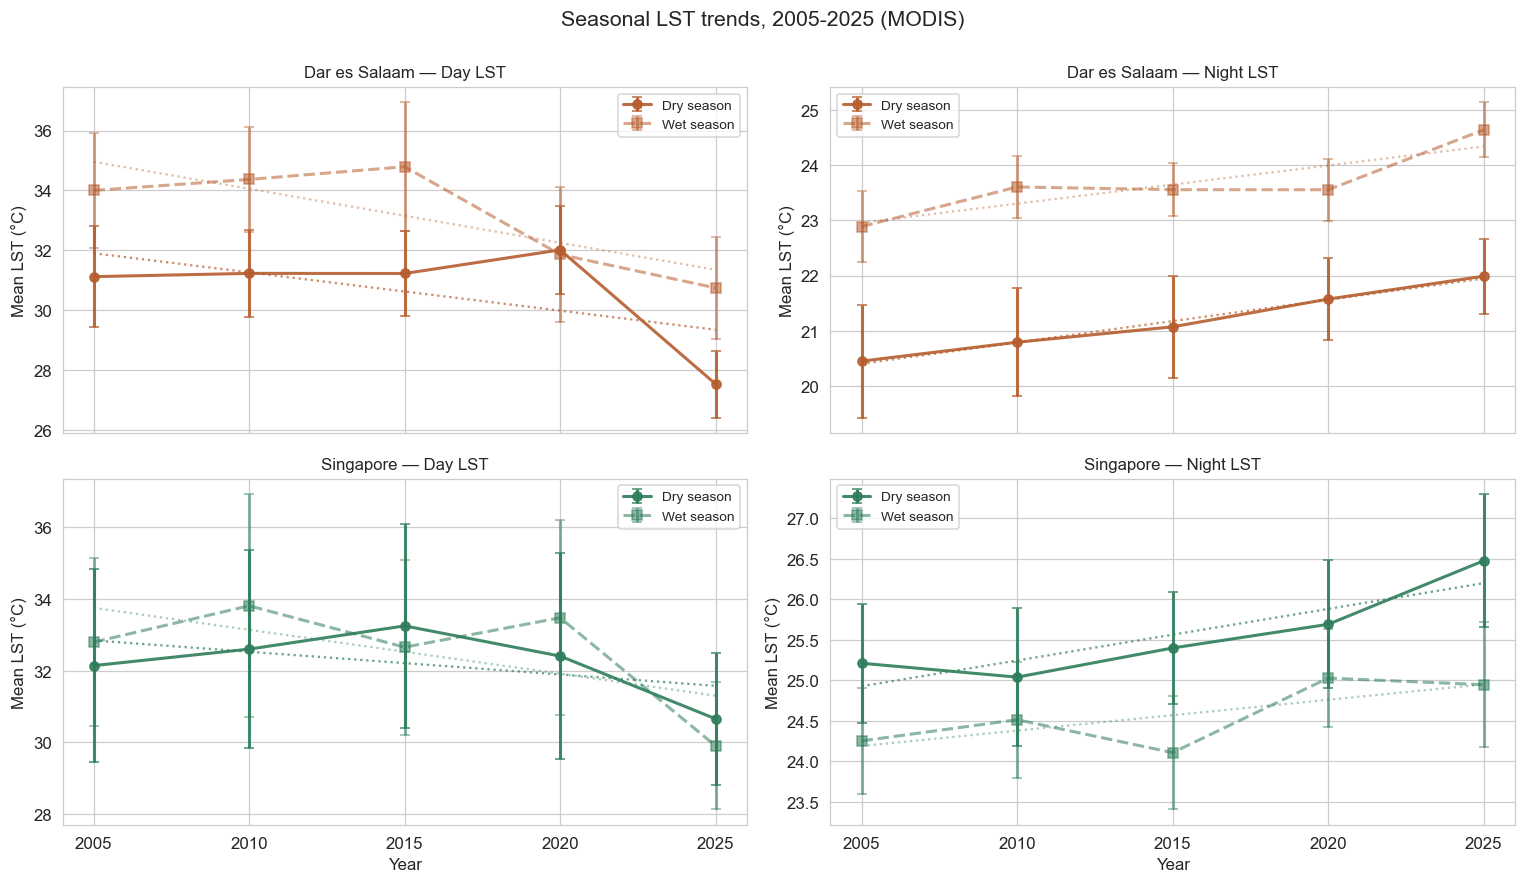

Saved: D:\uhi-dar-singapore\outputs\figures\07_seasonal_timeseries.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
city_colors = {'Dar es Salaam': '#B65D2E', 'Singapore': '#2E7D5B'}
season_styles = {'dry': {'ls': '-', 'marker': 'o'}, 'wet': {'ls': '--', 'marker': 's'}}

for col, tod in enumerate(['day', 'night']):
    for row, city in enumerate(['Dar es Salaam', 'Singapore']):
        ax = axes[row, col]
        for season in ['dry', 'wet']:
            sub = season_df[(season_df.city == city) &
                            (season_df.season == season) &
                            (season_df.tod == tod)].sort_values('year')
            ax.errorbar(sub['year'], sub['mean'], yerr=sub['std'],
                        color=city_colors[city],
                        alpha=0.55 if season == 'wet' else 0.9,
                        capsize=3, lw=2,
                        label=f'{season.capitalize()} season',
                        **season_styles[season])
            # Trend line
            reg = linregress(sub['year'], sub['mean'])
            x = np.array(sub['year'])
            ax.plot(x, reg.intercept + reg.slope*x, ls=':',
                    color=city_colors[city],
                    alpha=0.4 if season == 'wet' else 0.7)
        ax.set_title(f'{city} — {tod.capitalize()} LST', fontsize=11)
        ax.set_ylabel('Mean LST (°C)')
        if row == 1:
            ax.set_xlabel('Year')
        ax.set_xticks(YEARS)
        ax.legend(fontsize=9, loc='best')

plt.suptitle('Seasonal LST trends, 2005-2025 (MODIS)', fontsize=14, y=1.00)
plt.tight_layout()

out_dir = Path('../outputs/figures')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / '07_seasonal_timeseries.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {(out_dir / "07_seasonal_timeseries.png").resolve()}')

## 7. Figure 2 — Dry minus wet LST (seasonal contrast)

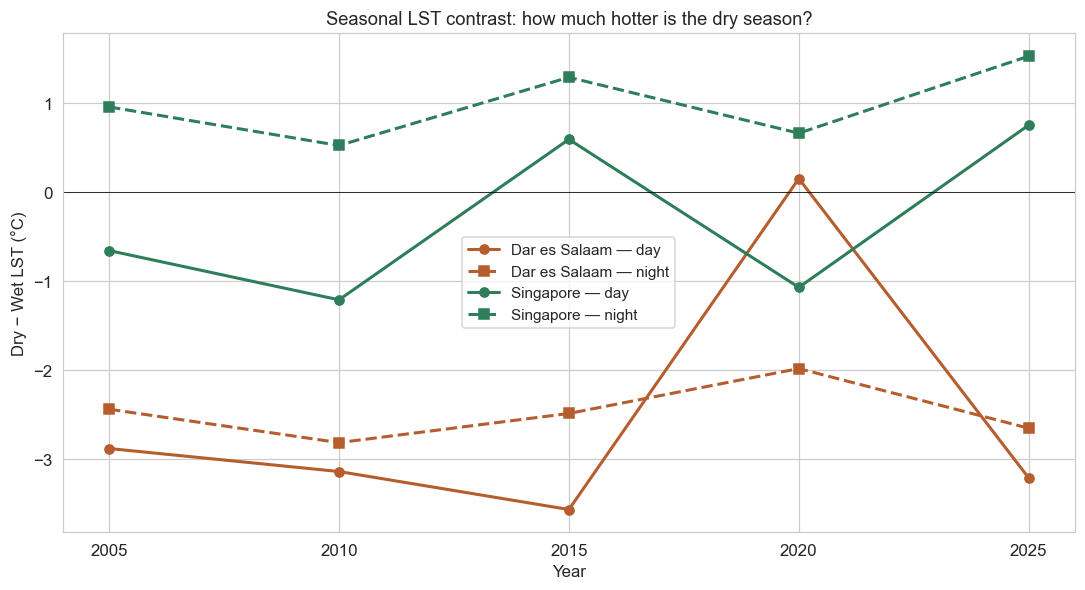

Saved: D:\uhi-dar-singapore\outputs\figures\07_seasonal_contrast.png


In [9]:
# Compute dry − wet per year × city × tod
pivot = (season_df
         .pivot_table(index=['city','year','tod'], columns='season', values='mean')
         .reset_index())
pivot['dry_minus_wet'] = pivot['dry'] - pivot['wet']

fig, ax = plt.subplots(figsize=(10, 5.5))
for city in ['Dar es Salaam', 'Singapore']:
    for tod, linestyle, marker in [('day', '-', 'o'), ('night', '--', 's')]:
        sub = pivot[(pivot.city == city) & (pivot.tod == tod)].sort_values('year')
        ax.plot(sub['year'], sub['dry_minus_wet'],
                marker=marker, linestyle=linestyle, lw=2,
                color=city_colors[city],
                label=f'{city} — {tod}')

ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Dry − Wet LST (°C)')
ax.set_title('Seasonal LST contrast: how much hotter is the dry season?', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.set_xticks(YEARS)

plt.tight_layout()
plt.savefig(out_dir / '07_seasonal_contrast.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {(out_dir / "07_seasonal_contrast.png").resolve()}')

### What to expect

For **Dar es Salaam**: dry-minus-wet contrast is **large** because the dry season gets full solar radiation with no cloud cover.

For **Singapore**: the contrast is **small** (often near zero) because equatorial cities are humid year-round and their wet and dry seasons are not thermally distinct.

If the contrast is *growing* over time, it hints at an intensifying dry season (reduced cloud cover, stronger UHI in dry months).

## 8. LCZ × season LST (Dar only, recent year)

For 2024 (latest with good data), we ask: does Dar's informal-settlement heat trap (LCZ 7 Lightweight) **intensify** in the dry season? Compute mean LST per LCZ per season using Landsat thermal.

In [10]:
# Landsat LST, seasonal
def get_landsat_lst_seasonal(geom, year, months):
    start = f'{year}-01-01'
    end   = f'{year}-12-31'

    def scale_lst(image):
        lst = (image.select('ST_B10')
                    .multiply(0.00341802).add(149.0).subtract(273.15)
                    .rename('LST'))
        return lst.copyProperties(image, ['system:time_start'])

    month_filters = [ee.Filter.calendarRange(m, m, 'month') for m in months]
    combined_filter = ee.Filter.Or(*month_filters) if len(month_filters) > 1 else month_filters[0]

    l8 = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
            .filterBounds(geom).filterDate(start, end)
            .filter(ee.Filter.lt('CLOUD_COVER', 30))
            .filter(combined_filter))
    l9 = (ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
            .filterBounds(geom).filterDate(start, end)
            .filter(ee.Filter.lt('CLOUD_COVER', 30))
            .filter(combined_filter))

    return l8.merge(l9).map(scale_lst).median().clip(geom).rename('LST')


# WUDAPT LCZ mosaic
lcz = (ee.ImageCollection("RUB/RUBCLIM/LCZ/global_lcz_map/latest")
         .mosaic().select('LCZ_Filter'))
lcz_dar = lcz.clip(dar_geom)
lcz_sgp = lcz.clip(sgp_geom)

LCZ_LABELS = {
    1: 'Compact HR',  2: 'Compact MR',  3: 'Compact LR',
    4: 'Open HR',     5: 'Open MR',     6: 'Open LR',
    7: 'Lightweight', 8: 'Large LR',    9: 'Sparsely built',
    10: 'Heavy industry',
    11: 'Dense trees', 12: 'Scattered trees', 13: 'Bush/scrub',
    14: 'Low plants', 15: 'Bare paved',  16: 'Bare soil', 17: 'Water',
}


def lcz_stats_seasonal(lst_img, lcz_img, geom, n_per_class=1500):
    lcz_proj = lcz_img.projection()
    lst_aligned = lst_img.select('LST').reproject(crs=lcz_proj, scale=100)
    stack = lst_aligned.addBands(lcz_img.select('LCZ_Filter').toInt().rename('lcz'))
    samples = stack.stratifiedSample(
        numPoints=n_per_class,
        classBand='lcz',
        region=geom,
        scale=100,
        seed=7,
        geometries=False,
        dropNulls=True,
    )
    df = geemap.ee_to_df(samples)
    if 'lcz' not in df.columns or 'LST' not in df.columns or len(df) == 0:
        return pd.DataFrame()
    df['lcz'] = df['lcz'].astype(int)
    df['label'] = df['lcz'].map(lambda i: LCZ_LABELS.get(i, f'class_{i}'))
    agg = df.groupby(['lcz','label'])['LST'].agg(['mean','std','count']).reset_index()
    agg['ci95'] = 1.96 * agg['std'] / np.sqrt(agg['count'])
    return agg


YEAR = 2024
lcz_season_stats = {}
for city, lcz_i, geom in [('Dar es Salaam', lcz_dar, dar_geom),
                          ('Singapore',     lcz_sgp, sgp_geom)]:
    for season, months in SEASONS[city].items():
        print(f"Computing {city} — {season} — {YEAR}...")
        lst_s = get_landsat_lst_seasonal(geom, YEAR, months)
        df = lcz_stats_seasonal(lst_s, lcz_i, geom)
        if len(df):
            df['city'] = city
            df['season'] = season
            lcz_season_stats[(city, season)] = df

# Combine
lcz_seasonal = pd.concat(lcz_season_stats.values(), ignore_index=True)
print(f"\nLCZ × season × LST rows: {len(lcz_seasonal)}")
lcz_seasonal.head(10)

Computing Dar es Salaam — dry — 2024...
Computing Dar es Salaam — wet — 2024...
Computing Singapore — dry — 2024...
Computing Singapore — wet — 2024...

LCZ × season × LST rows: 56


,lcz,label,mean,std,count,ci95,city,season
0,2,Compact MR,36.347117,0.593586,6,0.474968,Dar es Salaam,dry
1,3,Compact LR,37.795774,2.325743,1500,0.117699,Dar es Salaam,dry
2,6,Open LR,35.574349,2.196253,1500,0.111146,Dar es Salaam,dry
3,7,Lightweight,39.212347,1.080017,114,0.198260,Dar es Salaam,dry
4,8,Large LR,37.510290,2.284698,1500,0.115622,Dar es Salaam,dry
5,9,Sparsely built,33.707623,2.870310,1500,0.145258,Dar es Salaam,dry
6,10,Heavy industry,36.598626,0.947871,40,0.293748,Dar es Salaam,dry
7,11,Dense trees,29.426537,2.129737,1299,0.115818,Dar es Salaam,dry
8,12,Scattered trees,31.512670,2.892934,1500,0.146403,Dar es Salaam,dry
9,13,Bush/scrub,32.835873,3.035202,1500,0.153602,Dar es Salaam,dry


## 9. Figure 3 — LCZ seasonal contrast (dry − wet) per city

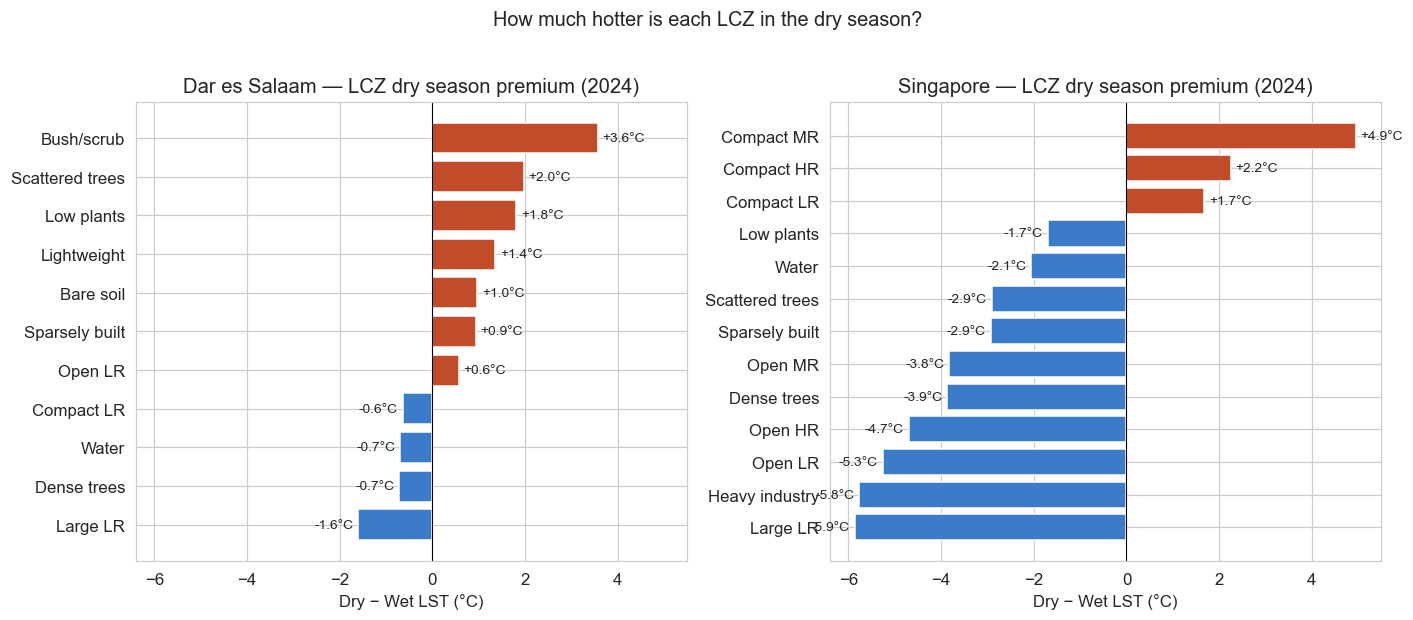

Saved: D:\uhi-dar-singapore\outputs\figures\07_lcz_seasonal_contrast.png


In [11]:
# Focus on LCZ types with meaningful counts
lcz_seasonal_clean = lcz_seasonal[lcz_seasonal['count'] >= 100].copy()

# Pivot to get dry and wet side-by-side per city × LCZ
lcz_pivot = (lcz_seasonal_clean
             .pivot_table(index=['city','label'], columns='season', values='mean')
             .reset_index())
lcz_pivot['dry_minus_wet'] = lcz_pivot['dry'] - lcz_pivot['wet']
lcz_pivot = lcz_pivot.dropna(subset=['dry','wet'])

# Plot: for each city, horizontal bar of dry-wet by LCZ
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True)

for ax, city in zip(axes, ['Dar es Salaam', 'Singapore']):
    sub = lcz_pivot[lcz_pivot.city == city].sort_values('dry_minus_wet', ascending=True)
    colors = ['#C14C2A' if v > 0 else '#3B7BC7' for v in sub['dry_minus_wet']]
    ax.barh(sub['label'], sub['dry_minus_wet'], color=colors)
    ax.axvline(0, color='black', lw=0.7)
    ax.set_title(f'{city} — LCZ dry season premium (2024)')
    ax.set_xlabel('Dry − Wet LST (°C)')
    # Value labels
    for i, v in enumerate(sub['dry_minus_wet']):
        x_off = 0.1 if v >= 0 else -0.1
        ax.text(v + x_off, i, f'{v:+.1f}°C',
                va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.suptitle('How much hotter is each LCZ in the dry season?', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(out_dir / '07_lcz_seasonal_contrast.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {(out_dir / "07_lcz_seasonal_contrast.png").resolve()}')

## 10. Export

In [12]:
out_tables = Path('../outputs/tables')
out_tables.mkdir(parents=True, exist_ok=True)

season_df.to_csv(out_tables / '07_seasonal_stats.csv', index=False)
season_trends.to_csv(out_tables / '07_seasonal_trends.csv', index=False)
lcz_seasonal.to_csv(out_tables / '07_lcz_seasonal.csv', index=False)

print('Saved:')
for p in sorted(out_tables.glob('07_*.csv')):
    print(f'  {p.resolve()}  ({p.stat().st_size/1024:.1f} KB)')

Saved:
  D:\uhi-dar-singapore\outputs\tables\07_lcz_seasonal.csv  (5.0 KB)
  D:\uhi-dar-singapore\outputs\tables\07_seasonal_stats.csv  (2.5 KB)
  D:\uhi-dar-singapore\outputs\tables\07_seasonal_trends.csv  (0.7 KB)


## 11. Interpretation notes for writeup

### Expected pattern 1: Dar's dry season amplifies UHI
If `dry_minus_wet` is positive and large (>2°C) for Dar's built LCZ types, you can say:
*"Dar's informal settlements are hottest in the dry season, when reduced cloud cover, lower humidity, and lack of evaporative cooling combine to push surface temperatures higher. Dry-season LST in LCZ 7 (Lightweight/informal settlements) is X°C warmer than wet-season LST in the same zones."*

### Expected pattern 2: Singapore shows minimal seasonality
Near-zero `dry_minus_wet` values across LCZs for Singapore reinforce the equatorial-climate stability story.

### Expected pattern 3: Warming is concentrated in the dry season
From Section 5, if Dar's dry-season trend is >1.5× the wet-season trend, you've shown that the 20-year warming is **disproportionately a dry-season phenomenon**. This is consistent with expected tropical climate change (drying of dry seasons in semi-arid regions).

### Tie-in with LCZ from notebook 05
Combine notebook 05's LCZ findings with these seasonal contrasts for a powerful conclusion:
- Dar's informal settlements (LCZ 7) are the hottest urban LCZ **and** amplify seasonally
- Singapore's heavy industry is hottest but stable year-round
- Dense trees maintain their cooling benefit in both seasons — vegetation is seasonally resilient

### Caveats
- Our Dar "wet" season spans non-contiguous months (Mar-May + Nov-Dec); a proper climatology would separate long rains and short rains
- Sample sizes in Dar drop during the wet season due to persistent cloud cover affecting Landsat but less so MODIS — differences in satellite-specific effective-sample-size could bias the Landsat LCZ comparison but not the MODIS time series